## Demonstrate fast search and parameter estimation of MBHB 
- Data: TDC II-0.2, the TDI-combined version ([data](https://zenodo.org/records/15469724/files/0_2_MBHB_TDIXYZ.h5?download=1), [parameters](https://zenodo.org/records/15532090/files/0_2_MBHB_parameters.h5?download=1)) 
- Template: TDI-2.0 response of ``IMRPhenomD`` waveform (implemented in ``WF4PY``) 
- Method: $\mathcal{F}$-statistics, differential evolution optimization, nested sampling via ``NESSAI``      
This example represents an idealized scenario where there is only one bright MBHB in the data. 

In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")

no cupy
no BBHx waveform


In [28]:
import os


DATA_DIR  = os.path.join(os.getcwd(), "TDCData", "0_2_MBHB_TDIXYZ.h5")
PARAM_DIR = os.path.join(os.getcwd(), "TDCData", "0_2_MBHB_parameters.h5")


ORBIT_DIR = os.path.abspath("../../Triangle-Simulator-master/OrbitData/MicroSateOrbitEclipticTCB")

print("当前工作目录:", os.getcwd())
print("DATA_DIR  :", DATA_DIR)
print("PARAM_DIR :", PARAM_DIR)
print("ORBIT_DIR :", ORBIT_DIR)


print(os.path.exists(DATA_DIR))
print(os.path.exists(PARAM_DIR))
print(os.path.exists(ORBIT_DIR))

当前工作目录: /home/doro/Triangle-BBH/Examples
DATA_DIR  : /home/doro/Triangle-BBH/Examples/TDCData/0_2_MBHB_TDIXYZ.h5
PARAM_DIR : /home/doro/Triangle-BBH/Examples/TDCData/0_2_MBHB_parameters.h5
ORBIT_DIR : /home/doro/Triangle-Simulator-master/OrbitData/MicroSateOrbitEclipticTCB
True
True
True


## Load data 

In [3]:
# the path of TDC data 
with h5py.File(DATA_DIR, "r") as h5file: 
    read_dict = read_dict_from_h5(h5file["/"])
    
# the path of parameters 
with h5py.File(PARAM_DIR, "r") as h5file: 
    injected_parameters = read_dict_from_h5(h5file["/"])
    
read_dict.keys(), injected_parameters.keys()

(dict_keys(['XYZ', 'time']),
 dict_keys(['chirp_mass', 'coalescence_phase', 'coalescence_time', 'inclination', 'latitude', 'longitude', 'luminosity_distance', 'mass_ratio', 'psi', 'spin_1z', 'spin_2z']))

### Combine AET and slice data near merger 
Assume that the merger time is roughly located (e.g. by whitening and examining the peak in time-domain data)

In [4]:
data_time = read_dict["time"]
A2_td, E2_td, _ = AETfromXYZ(read_dict["XYZ"]["X2"], read_dict["XYZ"]["Y2"], read_dict["XYZ"]["Z2"])
data_channels_td = -np.array([A2_td, E2_td]) # the convension of Michelson TDI-2.0 is different from Triangle-Simulator by a minus sign
channel_names = ["A2", "E2"] 
time_idx = np.where(
    (data_time/DAY >= injected_parameters["coalescence_time"] - 4) &
    (data_time/DAY <= injected_parameters["coalescence_time"] + 1)
)[0]

data_time = data_time[time_idx]
data_channels_td = data_channels_td[:, time_idx]

dt = data_time[1] - data_time[0]
Tobs = len(data_time) * dt

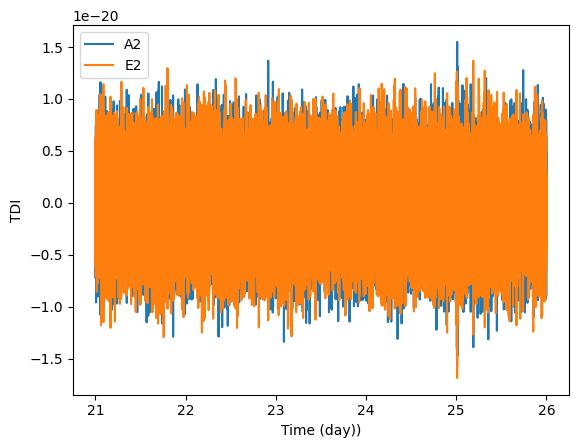

In [5]:
for i in range(len(data_channels_td)): 
    plt.plot(data_time/DAY, data_channels_td[i], label=channel_names[i])
plt.xlabel("Time (day))")
plt.ylabel("TDI")
plt.legend()

### Fourier transform 

In [6]:
data_channels_fd = [] 
for i in range(len(data_channels_td)): 
    ff, xf = FFT_window(
        data_array=data_channels_td[i], 
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=1000./Tobs)
    )
    data_channels_fd.append(xf) 
data_channels_fd = np.array(data_channels_fd) * np.exp(-TWOPI * 1.j * ff * data_time[0]) # shift to the "correct" time 
data_frequency = ff 

### Estimate noise PSD

In [7]:
ff, A2_PSD = PSD_window(
    data_array=A2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)
ff, E2_PSD = PSD_window(
    data_array=E2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)

psd_func_A2 = CubicSpline(ff, A2_PSD, extrapolate=True)
psd_func_E2 = CubicSpline(ff, E2_PSD, extrapolate=True)
psd_channels = np.array([
    psd_func_A2(data_frequency), 
    psd_func_E2(data_frequency)
])

/tmp/ipykernel_3262312/2290969887.py:3: RuntimeWarning: invalid value encountered in sqrt
  plt.loglog(data_frequency, np.sqrt(psd_channels[i] * Tobs / 2.), linestyle="--", label=channel_names[i]+" noise level")


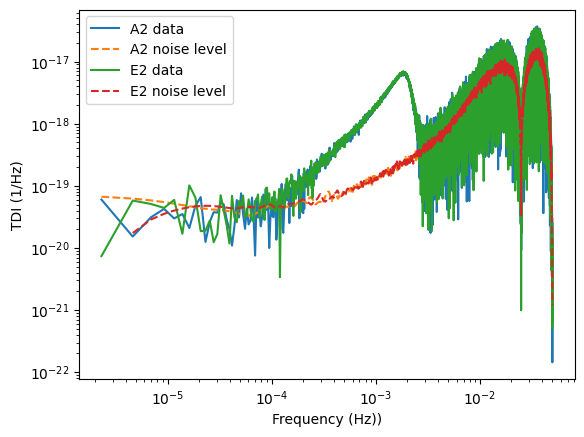

In [8]:
for i in range(len(data_channels_fd)): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data")
    plt.loglog(data_frequency, np.sqrt(psd_channels[i] * Tobs / 2.), linestyle="--", label=channel_names[i]+" noise level")
plt.xlabel("Frequency (Hz))")
plt.ylabel("TDI (1/Hz)")
plt.legend()

In [9]:
FMIN = 0.5e-4 
FMAX = 1e-2 
freq_idx = np.where((data_frequency>=FMIN)&(data_frequency<=FMAX))[0]
data_frequency = data_frequency[freq_idx]
data_channels_fd = data_channels_fd[:, freq_idx]
psd_channels = psd_channels[:, freq_idx]

## Models 

### waveform, response and noise

In [10]:
orbit = Orbit(OrbitDir=ORBIT_DIR)

# initialize  waveform generator 
WFG = WaveformGeneratorFRef(mode="primary")

# initialize response generator 
FDTDI = FDTDIResponseGeneratorFRef(orbit_class=orbit, waveform_generator=WFG)

# response settings 
response_kwargs_interp = dict(
    fmin=FMIN, 
    fmax=FMAX,
    # fref=1e-3, 
    modes=[(2,2),], 
    tmin=data_time[0]/DAY,
    tmax=data_time[-1]/DAY, 
    tref_at_constellation=True, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method='cubic',
)

response_kwargs_direct = dict(
    fmin=FMIN, 
    fmax=FMAX,
    # fref=1e-3, 
    modes=[(2,2),], 
    tmin=data_time[0]/DAY,
    tmax=data_time[-1]/DAY, 
    tref_at_constellation=True, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation_method=None,
)

# covariance matrix
CovMat = np.array([
    [psd_channels[0], np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), psd_channels[1]],
]) / 4. * Tobs 

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) 

response_kwargs_interp, InvCovMat.shape 

({'fmin': 5e-05,
  'fmax': 0.01,
  'modes': [(2, 2)],
  'tmin': 21.0,
  'tmax': 26.0,
  'tref_at_constellation': True,
  'TDIGeneration': '2nd',
  'optimal_combination': True,
  'drop_T': True,
  'interpolation_method': 'cubic'},
 (4299, 2, 2))

In [11]:
injected_parameters_fref = injected_parameters.copy()
injected_parameters_fref["reference_time"] = injected_parameters["coalescence_time"]
injected_parameters_fref["reference_phase"] = injected_parameters["coalescence_phase"]
FDTDI.Response(
    parameters=injected_parameters_fref, 
    freqs=data_frequency, 
    **response_kwargs_direct
)

array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]])

## Search high-likelihood parameters with $\mathcal{F}$-statistics

### set priors for the "intrinsic" parameters (dimension = 11 - 4)

In [12]:
lgMc_prior = [5., 7.]
q_prior = [0.01, 0.99]
s1_prior = [-0.99, 0.99]
s2_prior = [-0.99, 0.99]
tc_prior = [injected_parameters["coalescence_time"]-0.1, injected_parameters["coalescence_time"]+0.1] 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

### initialize $\mathcal{F}$-statitsitcs

In [13]:
Fstat = FstatisticsFref(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_interp, 
    use_gpu=False, 
)

### search in prior 

In [14]:
def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams), normalized to (0, 1)
    """
    try: 
        int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nparams)
        params_in = Fstat.IntParamArr2ParamDict(int_params) # (Nparams) -> dictionary
        return -Fstat.calculate_Fstat(intrinsic_parameters=params_in) # float
    except np.linalg.LinAlgError:
        return np.infty 

n_dim_int = 7 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    maxiter=1000,
    popsize=5*n_dim_int,
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=False,
    workers=-1, 
)

DE_result

/home/doro/miniconda3/envs/tri_env/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/doro/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:305: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2)
/home/doro/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:199: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), np.fabs(fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2))
/home/doro/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:305: Run

             message: Optimization terminated successfully.
             success: True
                 fun: -595034.3379242636
                   x: [ 7.384e-01  2.459e-01  6.973e-01  8.208e-01
                        2.147e-01  7.432e-01  5.854e-01]
                 nit: 261
                nfev: 64190
          population: [[ 7.384e-01  2.459e-01 ...  7.432e-01  5.854e-01]
                       [ 7.384e-01  2.458e-01 ...  7.359e-01  5.918e-01]
                       ...
                       [ 7.383e-01  2.458e-01 ...  7.470e-01  5.608e-01]
                       [ 7.384e-01  2.459e-01 ...  7.390e-01  5.974e-01]]
 population_energies: [-5.950e+05 -5.950e+05 ... -5.950e+05 -5.950e+05]

### Reconstruct other parameters and waveform 

In [15]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = Fstat.calculate_Fstat(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic(searched_a)
searched_parameters = dict(searched_int_params, **searched_ext_params)

searched_wf = FDTDI.Response(
    searched_parameters, 
    data_frequency, 
    **response_kwargs_interp, 
)

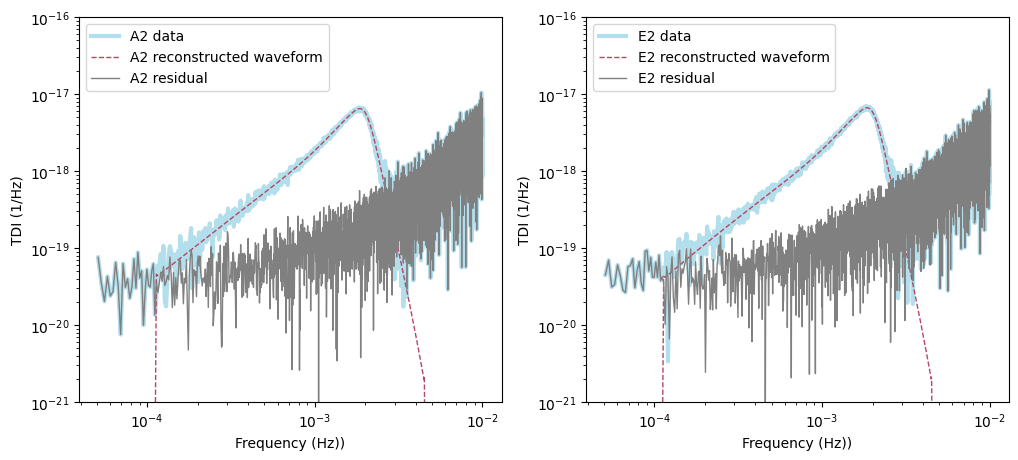

In [16]:
plt.figure(figsize=(12, 5))
for i in range(len(data_channels_fd)): 
    plt.subplot(121+i)
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data", color=BLUE, linewidth=3, alpha=0.5)
    plt.loglog(data_frequency, np.abs(searched_wf[i]), label=channel_names[i]+" reconstructed waveform", color=RED, linewidth=1, linestyle="--")
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]-searched_wf[i]), label=channel_names[i]+" residual", color="grey", linewidth=1)
    plt.xlabel("Frequency (Hz))")
    plt.ylabel("TDI (1/Hz)")
    plt.legend(loc="upper left")
    plt.ylim(1e-21, 1e-16)

## Fisher analysis around the searched parameters 

In [17]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        parameters=param_dict, 
        freqs=np.array(frequencies),  
        **response_kwargs_interp, 
    )
    return res

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'reference_time': 0.001,
    'reference_phase': 0.01,
    'luminosity_distance': 10.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=searched_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequency, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 2154.919918917733,
 'mass_ratio': 0.0006572474610926676,
 'spin_1z': 0.003311689655539675,
 'spin_2z': 0.014642246485002824,
 'reference_time': 0.000158220656076297,
 'reference_phase': 3.1706981974995623,
 'luminosity_distance': 6618.87665638445,
 'inclination': 0.0035618532307036526,
 'longitude': 0.20969418774465476,
 'latitude': 0.26492309533136904,
 'psi': 0.08860942821186563}

## Likelihood

### initialize heterodyned likelihood 

In [18]:
Like = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_direct, 
    Fref_waveform=True, 
    use_gpu=False,
)

Like.prepare_het_log_like(base_parameters=ParamDict2ParamArrFref(searched_parameters))

### create bilby wrapper 

In [19]:
import bilby 
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="heterodyned"):
        """ 
            type can be "heterodyned" or "full"
        """
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        self.like_type = type 

    def log_likelihood(self):
        if self.like_type == "heterodyned": 
            # convert to single precision to avoid instability of the sampler
            return np.float32(Like.het_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters)))
        else: 
            return np.float32(Like.full_log_like(parameter_array=ParamDict2ParamArrFref(self.parameters)))

## Prior 

In [20]:
# set prior to be 10 sigma around the truths 
priors = bilby.core.prior.PriorDict()
priors["chirp_mass"] = bilby.prior.Uniform(minimum=searched_parameters["chirp_mass"]-10.*FIM.param_errors["chirp_mass"], maximum=searched_parameters["chirp_mass"]+10.*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, searched_parameters["mass_ratio"]-10.*FIM.param_errors["mass_ratio"]), maximum=min(0.99, searched_parameters["mass_ratio"]+10.*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_parameters["spin_1z"]-10.*FIM.param_errors["spin_1z"]), maximum=min(0.9, searched_parameters["spin_1z"]+10.*FIM.param_errors["spin_1z"]), name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_parameters["spin_2z"]-10.*FIM.param_errors["spin_2z"]), maximum=min(0.9, searched_parameters["spin_2z"]+10.*FIM.param_errors["spin_2z"]), name="spin_2z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=searched_parameters["reference_time"]-10.*FIM.param_errors["reference_time"], maximum=searched_parameters["reference_time"]+10.*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(6e3, searched_parameters["luminosity_distance"]-10.*FIM.param_errors["luminosity_distance"]), maximum=min(1e5, searched_parameters["luminosity_distance"]+10.*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

priors

{'chirp_mass': Uniform(minimum=2975901.7391111217, maximum=3019000.1374894762, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.24442393508158108, maximum=0.25756888430343444, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': Uniform(minimum=0.3575091704358069, maximum=0.42374296354660035, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None),
 'spin_2z': Uniform(minimum=0.48867773487481486, maximum=0.7815226645748714, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None),
 'reference_time': Uniform(minimum=24.941363901826225, maximum=24.94452831494775, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None),
 'reference_phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', latex_label='$\\varphi_\\mathrm{ref}$', unit=None, boundary='periodic'),
 'luminosity_distance': Uniform(minimum=6000.0, maximum=100000.0, name=

## Run nested sampling 

In [21]:
# the parameterization of time and phase parameters are different, so we set the truths of these two parameters to None 
show_parameters = injected_parameters.copy()
show_parameters.pop("coalescence_time")
show_parameters.pop("coalescence_phase")
show_parameters["reference_time"] = None 
show_parameters["reference_phase"] = None 

In [23]:
BLike = bilby_likelihood_wrapper()

ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

result = bilby.run_sampler(
    likelihood=BLike, 
    priors=priors,
    sampler="nessai", 
    nlive=1000,
    stopping=0.1, 
    npool=ncpu, # use all cpus 
    injection_parameters=injected_parameters, 
    outdir="Samples",
    label="vmbhb_example",
    plot=True,
    # resume=False, 
    resume=True, 
)

09:59 bilby INFO    : Running for label 'vmbhb_example', output will be saved to 'Samples'


number of cpus = 8


09:59 bilby INFO    : Analysis priors:
09:59 bilby INFO    : chirp_mass=Uniform(minimum=2975901.7391111217, maximum=3019000.1374894762, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
09:59 bilby INFO    : mass_ratio=Uniform(minimum=0.24442393508158108, maximum=0.25756888430343444, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
09:59 bilby INFO    : spin_1z=Uniform(minimum=0.3575091704358069, maximum=0.42374296354660035, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None)
09:59 bilby INFO    : spin_2z=Uniform(minimum=0.48867773487481486, maximum=0.7815226645748714, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None)
09:59 bilby INFO    : reference_time=Uniform(minimum=24.941363901826225, maximum=24.94452831494775, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None)
09:59 bilby INFO    : reference_phase=Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', la

03-27 09:59 nessai INFO    : Running Nessai version 0.15.2
03-27 09:59 nessai INFO    : Starting multiprocessing pool with 8 processes
03-27 09:59 nessai INFO    : Trying to resume sampler from Samples/vmbhb_example_nessai/nested_sampler_resume.pkl
03-27 09:59 nessai INFO    : Resuming NestedSampler from Samples/vmbhb_example_nessai/nested_sampler_resume.pkl
03-27 09:59 nessai INFO    : Resuming instance of NestedSampler
03-27 09:59 nessai WARNING : Signal handling is disabled. nessai will not automatically checkpoint when exited.
03-27 09:59 nessai INFO    : Already using flowproposal
03-27 09:59 nessai INFO    : Starting nested sampling loop
03-27 09:59 nessai WARNING : NS integrator received non-monotonic logL.588574.37500 -> 588574.37500
03-27 09:59 nessai INFO    : it: 13568: n eval: 8508561 H: 19.53 dlogZ: 5817.149 logZ: 588554.659 +/- 0.140 logLmax: 594385.38
03-27 10:00 nessai INFO    : it: 13601: n eval: 8588561 H: 19.47 dlogZ: 5751.023 logZ: 588620.752 +/- 0.140 logLmax: 5943

08:03 bilby INFO    : Sampling time: 2 days, 10:27:24.582923
08:03 bilby INFO    : Summary of results:
nsamples: 4802
ln_noise_evidence:    nan
ln_evidence: 594945.377 +/-  0.187
ln_bayes_factor:    nan +/-  0.187



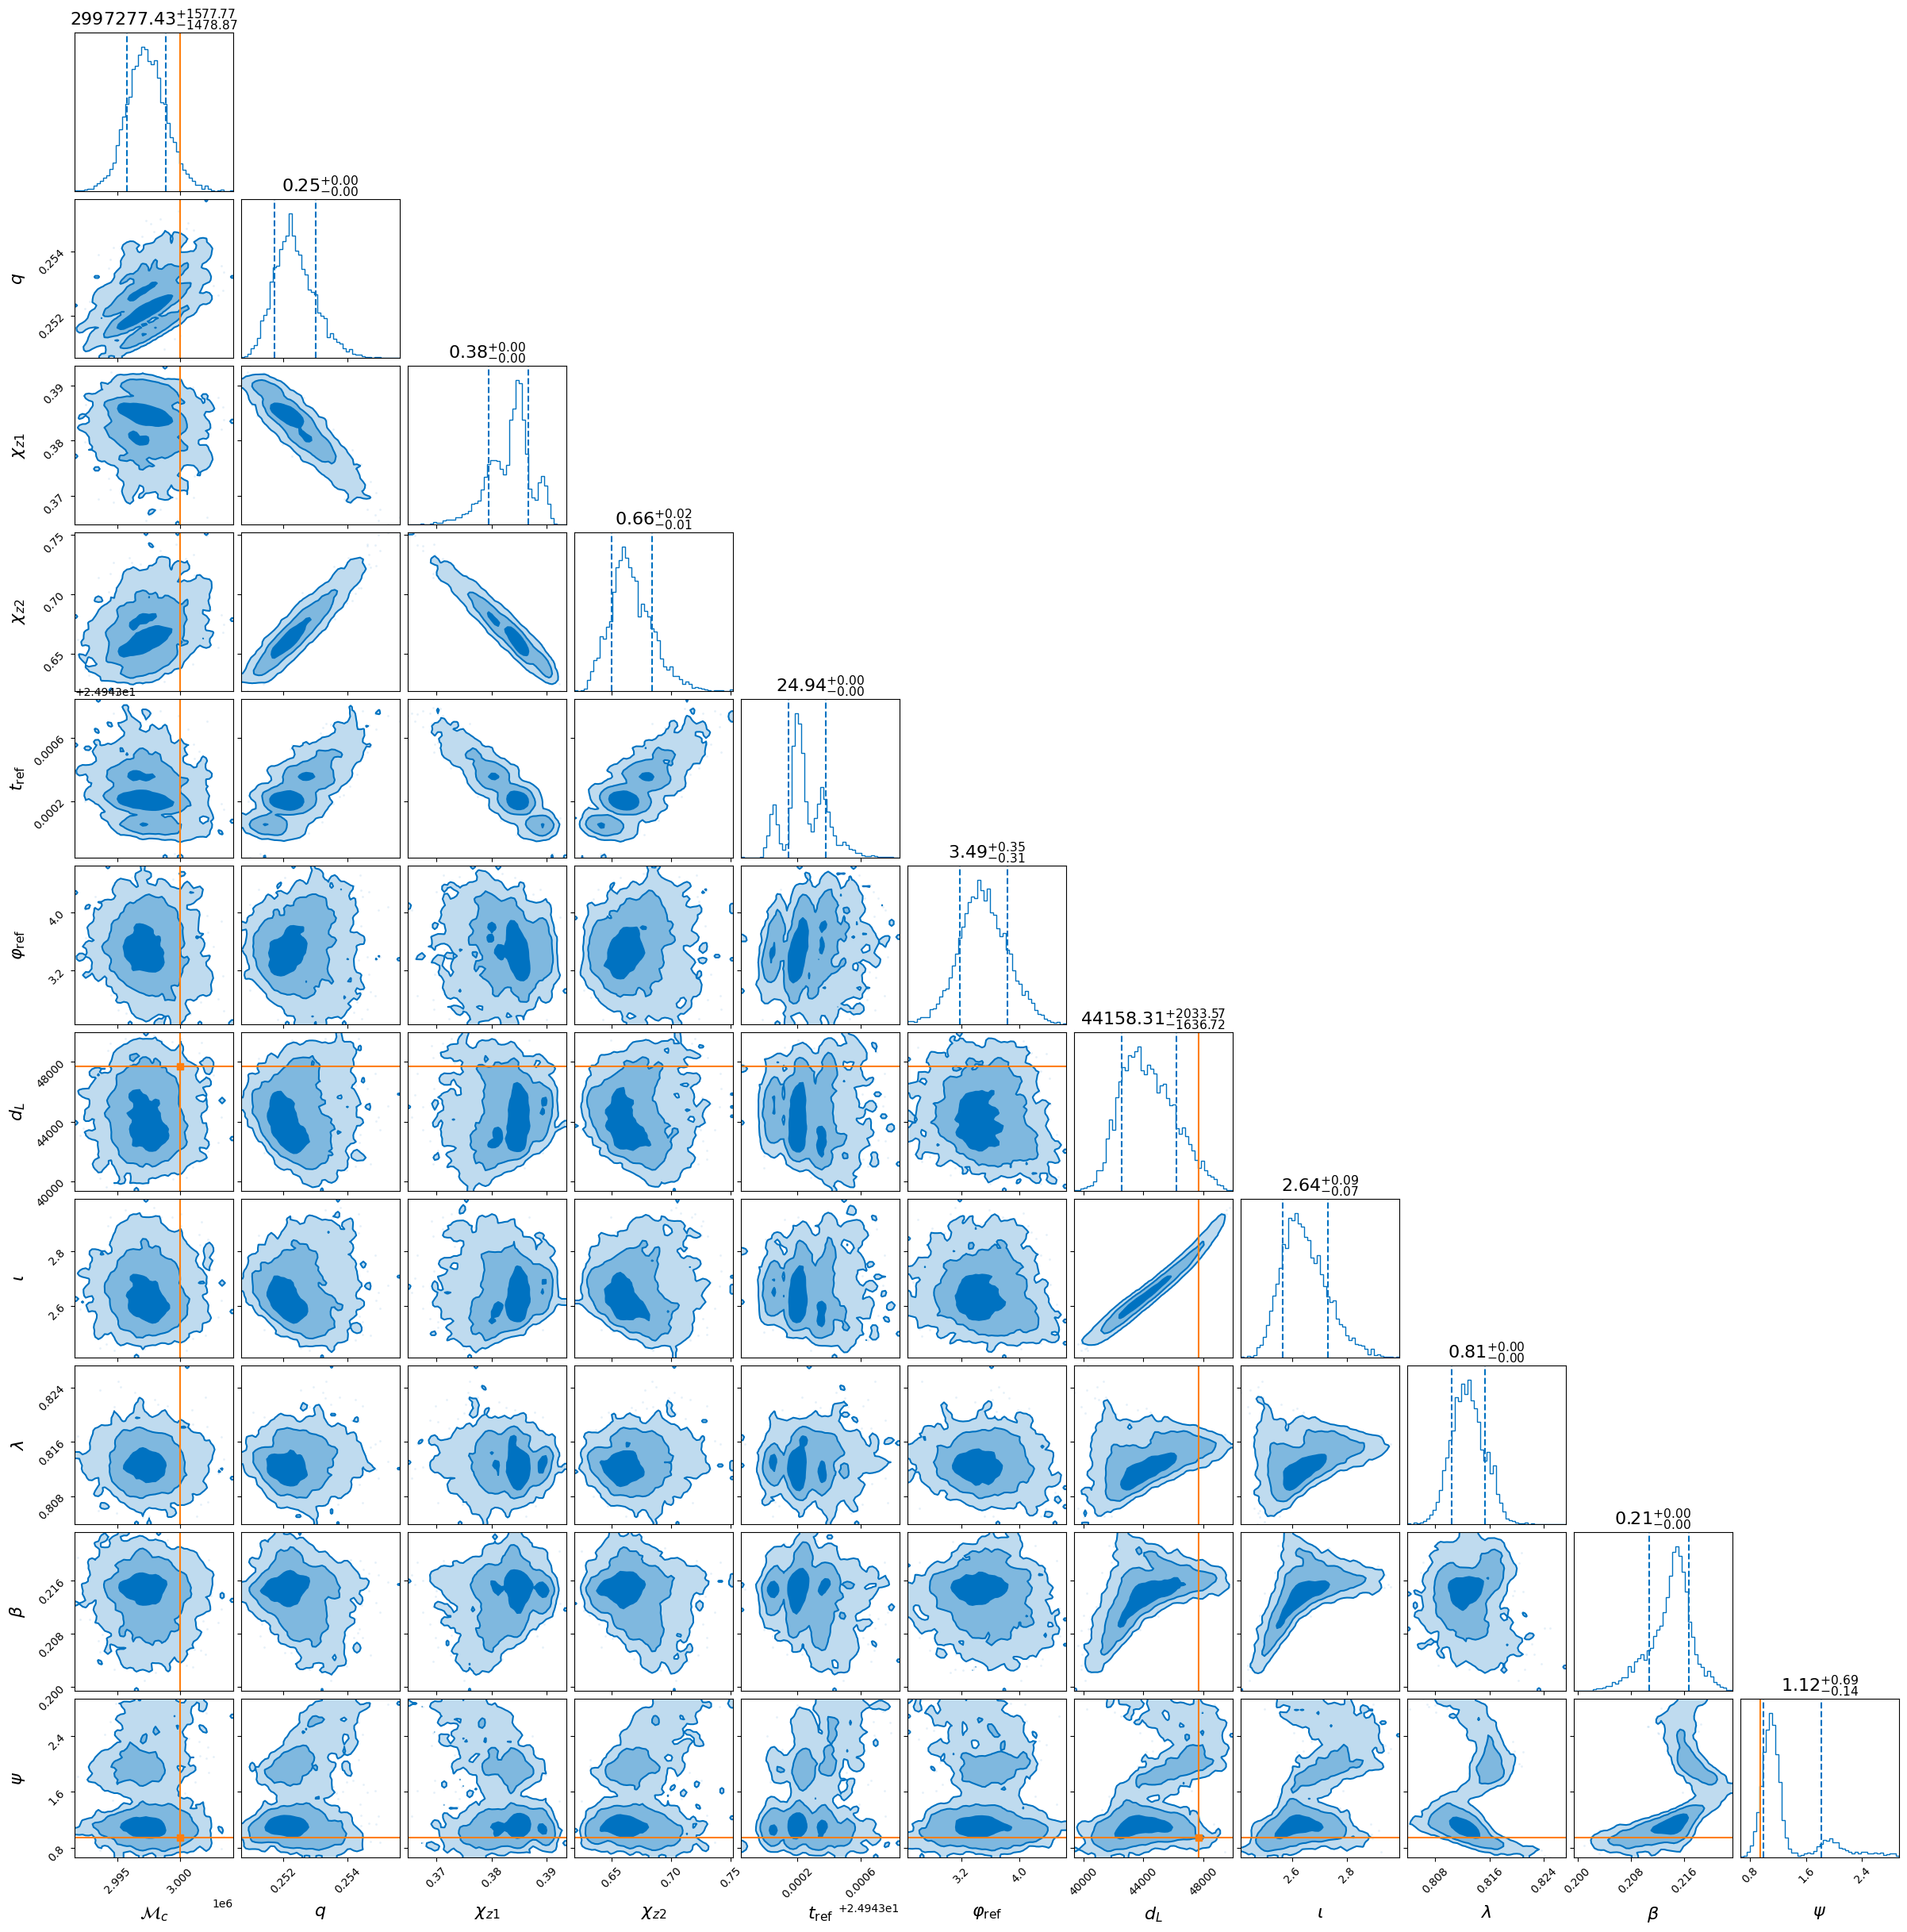

In [24]:
result.plot_corner(save=True)

### Some insights based on the posterior: 
- multi-modality of sky position, inclination, and polarization angle (reflected mode) $\rightarrow$ potential of wrong localization using MLE 
- multi-modality of phase parameter due to the exclusion of higher-order modes 
- verification of the consistency between time-domain respoonse (TDC II-0.2 data, generated using Triangle-Simulator) and frequency-domain response (Triangle-BBH) for this case 
- compare with Fisher analysis

In [25]:
searched_parameters_reflected = get_reflected_parameter_dict_Fref(searched_params=searched_parameters, orbit=orbit)
print("parameter | true | searched | searched (reflected)")
for pn in ["longitude", "latitude"]:
    print(pn, injected_parameters[pn], searched_parameters[pn], searched_parameters_reflected[pn])

parameter | true | searched | searched (reflected)
longitude 4.71238898038469 4.669616872786235 2.2702803181777123
latitude 0.5235987755982988 0.17170295608972755 -0.8174026503922875
